In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="2"
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

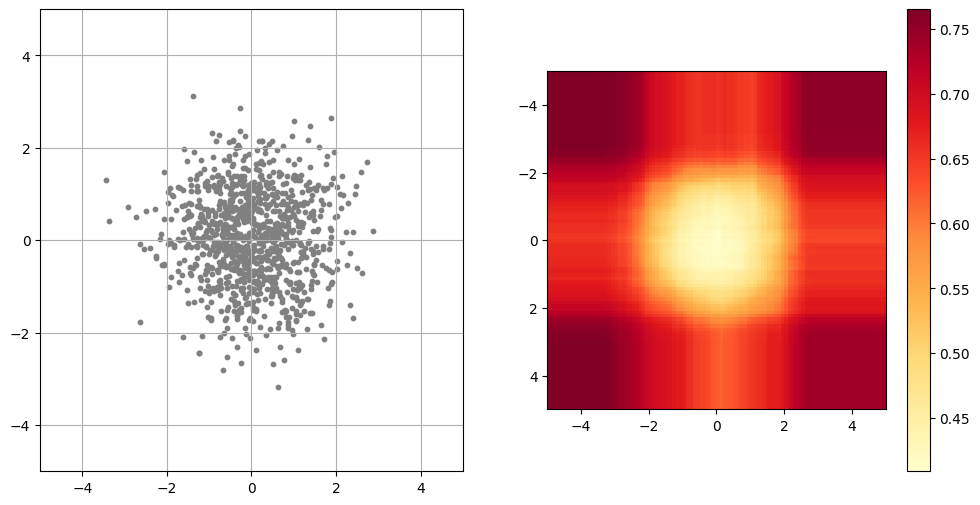

In [2]:
from isolation_forest import ExtendedIsolationForest

n_trees = 128
subsample_size = 256
hyperplane_components = 1

rng_data, rng_forest = jax.random.split(jax.random.PRNGKey(42))
data = jax.random.normal(rng_data, (1024, 2))
forest = ExtendedIsolationForest.fit(rng_forest, data, n_trees, subsample_size, hyperplane_components)

X, Y = jnp.meshgrid(jnp.linspace(-5, 5, 100), jnp.linspace(-5, 5, 100))
coord = jnp.stack([X.flatten(), Y.flatten()]).T
scores = forest.score_samples(coord)
plt.figure(figsize=(12, 6))
plt.subplot(122)
plt.imshow(scores.reshape(100, 100), extent=(-5, 5, 5, -5), cmap="YlOrRd")
plt.colorbar()
plt.subplot(121)
plt.scatter(data[:, 0], data[:, 1], marker="o", c="grey", s=10)
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid()
plt.show()

In [3]:
n_trees = 128
subsample_size = 256
n_dim = 2
hyperplane_components = 1

In [4]:
rng_data, rng_forest = jax.random.split(jax.random.PRNGKey(42))
data = jax.random.normal(rng_data, (10000, n_dim))
forest = ExtendedIsolationForest.fit(rng_forest, data, n_trees, subsample_size, hyperplane_components)
scores = forest.score_samples(data)
%timeit ExtendedIsolationForest.fit(rng_forest, data, n_trees, subsample_size, hyperplane_components).trees.node_sizes.block_until_ready()
%timeit forest.score_samples(data).block_until_ready()

935 µs ± 22.5 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.34 ms ± 233 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [5]:
vectorized_fit = jax.vmap(ExtendedIsolationForest.fit, in_axes=(0, None, None, None, None))
vectorized_score = jax.vmap(ExtendedIsolationForest.score_samples, in_axes=(0, None))
rng = jax.random.split(jax.random.PRNGKey(42), 32)
forests = vectorized_fit(rng, data, n_trees, subsample_size, hyperplane_components)
scores = vectorized_score(forests, data)
%timeit vectorized_fit(rng, data, n_trees, subsample_size, hyperplane_components).trees.node_sizes.block_until_ready()
%timeit vectorized_score(forests, data).block_until_ready()

26.5 ms ± 83.2 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
55 ms ± 40 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [6]:
from sklearn.ensemble import IsolationForest
import numpy as np
data = np.random.normal(size=(10000, n_dim))
model = IsolationForest(                   
    n_estimators=n_trees,
    max_samples=subsample_size,
)
model.fit(data)
%timeit model.fit(data)
%timeit model.score_samples(data)

110 ms ± 1.15 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
46.9 ms ± 134 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
